# TME ROBOTIQUE ET APPRENTISSAGE
# Evolution de structures

Version étudiant 2025-2026

*mise à jour: 07/04/2026*

Ce notebook peut être exécuté dans [Google Colab](https://colab.research.google.com/)


Vous devez déposer votre travail sur Moodle:
* déposer votre notebook, avec le nom de fichier *obligatoirement* au format suivant: **RA_NOM1_NOM2.ipynb**
* toutes les cellules exécutées
* les graphes et les commentaires demandés
* affichage limité au nécessaire pour assurer la lisibilité du notebook (pas d'affichage de debug ni de centaines de graphes !)

*Le sujet est à faire en binome.*

### COMPLETEZ LES CHAMPS CI-DESSOUS AVEC NOM/PRENOM/CARTE_ETU:

* Étudiant 1: **_ZHANG_ _Yuxiang_ 21202829**
* Étudiant 2: **_Alsafadi_ _Kenan_ _21502362_**

## 1. Introduction

Ce TME est s'appuie sur le framework DEAP que vous avez utilisé lors du TME précédent. 

Il porte sur l'application de la programmation génétique au problème de régression symbolique. Dans les méthodes que nous allons implémenter, le génotype d'un individu n'est plus une liste de paramètres continus, mais un graphe correspondant à une expression symbolique. Les opérateurs d'initialisation, de mutation et de croisement seront différents de ceux vus au TME1 car ils doivent être adaptés au type d'individu que l'on manipule.

Un graphe symbolique est une structure de données permettant de représenter une expression mathématique.

Par exemple, le graphe représenté ci-dessous correspond à l'expression $1 - \cos(2x)$

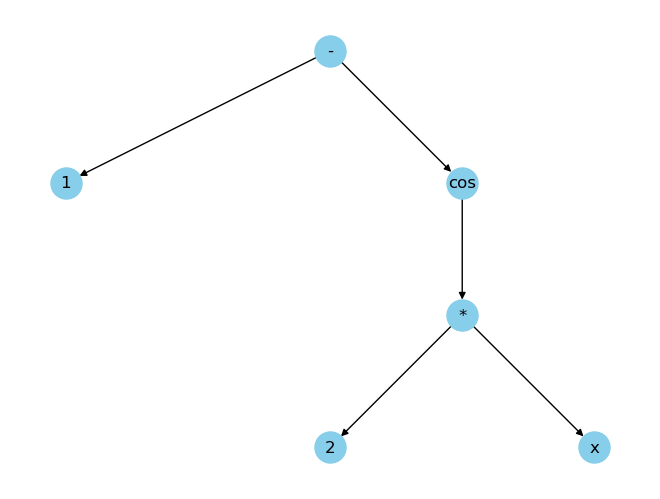

Dans un graphe d'expression, les noeuds peuvent correspondre:
- A des opérateurs binaires (les noeuds ont deux enfants): addition, soustraction, etc.
- A des opérateurs unaires (les noeuds ont un enfant): sinus, cosinus, exponentielle, logarithme, etc.
- A des noeuds dits terminaux (sans enfants), qui peuvent être soit des constantes (exemple: 1 et 2 dans la figure) soit des variables (exemple: $x$)

Le problème de la régression symbolique est de trouver l'expression mathématique (représentée par un graphe) qui correspond le mieux à un jeu de données fourni. C'est un problème d'apprentissage supervisé avec des données de la forme $(x, y)$. Le but est de trouver l'expression d'une fonction $f: x\to y'=f(x)$ minimisant l'erreur de prédiction entre $y'$ et $y$.

Nous avons donc déjà de quoi définir:
- nos individus: des graphes représentant des expressions symboliques $f$ calculant $y'$ en fonction des entrées $x$
- la fitness de nos individus: l'erreur de prédiction entre $y'=f(x)$ et $y$

La documentation de DEAP (https://deap.readthedocs.io/en/master/api/index.html) vous permet d'avoir des explications sur les différents opérateurs et algorithmes.

Installation des dépendances:

In [1]:
!pip install deap
!pip install networkx
!pip install matplotlib
!pip install numpy

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [2]:
from deap import creator, gp, base, tools, algorithms
from matplotlib import pyplot as plt
import math
import numpy as np
import operator
import random
from utils import plot_symbolic_tree

## 2. Données

Dans le TME1, nous avons vu comment un algorithme évolutionniste pouvait trouver des politiques pour le contrôle d'un bras 2D. Dans ce TP, nous allons à la place voir comment ces algorithmes peuvent découvrir les équations du mouvement du même bras 2D à partir de données d'interaction avec l'environnement.

Les données sont générées en simulant un bras en 2D possédant deux articulations (épaule et coude). On note $\theta_1$ et $\theta_2$ les angles des deux articulations, et on définit deux fonctions `pos_x(theta_1, theta_2)` et `pos_y(theta_1, theta_2)` calculant la position en $x$ et en $y$ respectivement de l'effecteur final du bras 2D:

In [3]:
def pos_x(theta_1, theta_2):
    # Calcul de la position en x de l'effecteur en fonction des angles des moteurs
    return np.cos(theta_1) + np.cos(theta_1 + theta_2)


def pos_y(theta_1, theta_2):
    # Calcul de la position en y de l'effecteur en fonction des angles des moteurs
    return np.sin(theta_1) + np.sin(theta_1 + theta_2)

On suppose que ces fonctions sont inconnues de l'agent contrôlant le robot. L'agent peut tirer des valeurs de $\theta_1$ et $\theta_2$ au hasard et mesurer la position obtenue en bougeant son bras, et ainsi se construire un jeu de données $\mathcal D = (\theta, x)_i$ avec, pour chaque échantillon $i$,  $\theta_i = (\theta_{1, i}, \theta_{2, i})$ et $x_i = \texttt{pos\_x}(\theta_{1, i}, \theta_{2, i})$. La régression symbolique correspond à la tâche de retrouver les équations mathématiques à partir des données. Dans notre cas, le but est donc de retrouver une expression mathématique correspondant à la fonction `pos_x`, uniquement à partir des inputs et outputs de cette fonction.

La fonction `generate_data` permet de construire un tel jeu de données. Dans le reste du TME nous allons nous concentrer uniquement sur la prédiction sur la position en $x$, mais exactement les mêmes méthodes peuvent être utilisées pour la prédiction sur la position en $y$.

In [4]:
def generate_data(n_points, train_split, test_split, noise):
    # Génère des données d'entraînement et de test pour la fonction x(theta_1, theta_2)
    inputs = []
    outputs = []
    theta_1 = np.arange(0, 2*math.pi*(n_points) /
                        (n_points-1), 2*math.pi/(n_points-1))
    theta_2 = np.arange(0, 2*math.pi*(n_points) /
                        (n_points-1), 2*math.pi/(n_points-1))
    for i in range(n_points):
        for j in range(n_points):
            inputs.append([theta_1[i], theta_2[j]])
            output = pos_x(theta_1[i], theta_2[j])
            outputs.append(output)
    inputs = np.array(inputs)
    outputs = np.array(outputs) + \
        noise * np.random.randn(n_points**2)
    n_train = int(train_split * n_points**2)
    n_test = int(test_split * n_points**2)

    permutation = np.random.permutation(n_train+n_test)
    train_inputs = inputs[:n_train+n_test][permutation][:n_train]
    train_outputs = outputs[:n_train+n_test][permutation][:n_train]
    test_inputs = inputs[:n_train+n_test][permutation][n_train:n_train+n_test]
    test_outputs = outputs[:n_train + n_test][permutation][n_train:n_train+n_test]
    ood_inputs = inputs[n_train+n_test:]
    ood_outputs = outputs[n_train+n_test:]
    return train_inputs, train_outputs, test_inputs, test_outputs, ood_inputs, ood_outputs

Exemple d'utilisation pour une grille de 9×9 points échantillonés, 80% des points dans le jeu d'entraînement et 20% dans le jeu de test, et un bruit d'amplitude 0.1.

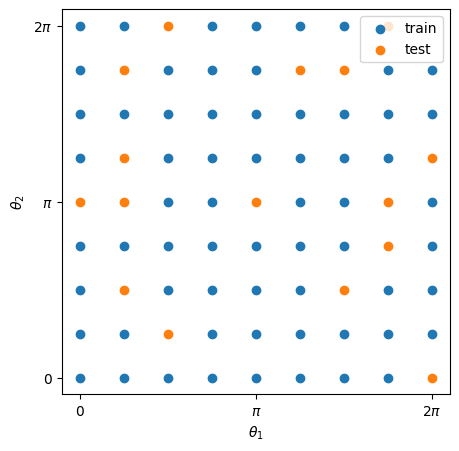

In [7]:
np.random.seed(0)

train_inputs, train_outputs, test_inputs, test_outputs, ood_inputs, ood_outputs = generate_data(
    n_points=9, train_split=0.8, test_split=0.2, noise=0.1)

# Affichage des données
plt.figure(figsize=(5, 5))
plt.scatter(train_inputs[:, 0], train_inputs[:, 1], label='train')
plt.scatter(test_inputs[:, 0], test_inputs[:, 1], label='test')
plt.xticks([0, math.pi, 2*math.pi], ['0', r'$\pi$', r'$2\pi$'])
plt.yticks([0, math.pi, 2*math.pi], ['0', r'$\pi$', r'$2\pi$'])
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.axis('equal')
plt.legend()
plt.show()

La fonction suivante permet de tracer une fonction donnée f($\theta_1$, $\theta_2$) en fonction de $\theta_1$, pour plusieurs valeurs de $\theta_2$:

Le module `utils.py` fournit une fonction `display_function` permettant de tracer une fonction donnée $f$ qui prend en entrée $\theta_1$ et $\theta_2$. La figure représente l'évolution de $f(\theta_1, \theta_2) en fonction de $\theta_1$ pour trois valeurs de $\theta_2$.

On peut l'appeler avec n'importe quelle fonction pouvant prendre en paramètre deux numpy array de même taille. 

La cellule suivante montre un exemple avec en entrée la fonction $cos(\theta_1 + \theta_2)$. La courbe noire représente la vraie fonction qui a généré les données (la fonction `pos_x`), les points bleus et orange correspondent aux données d'entraînement et de test, et la courbe bleue représente la prédiction obtenue avec la fonction donnée en paramètre.

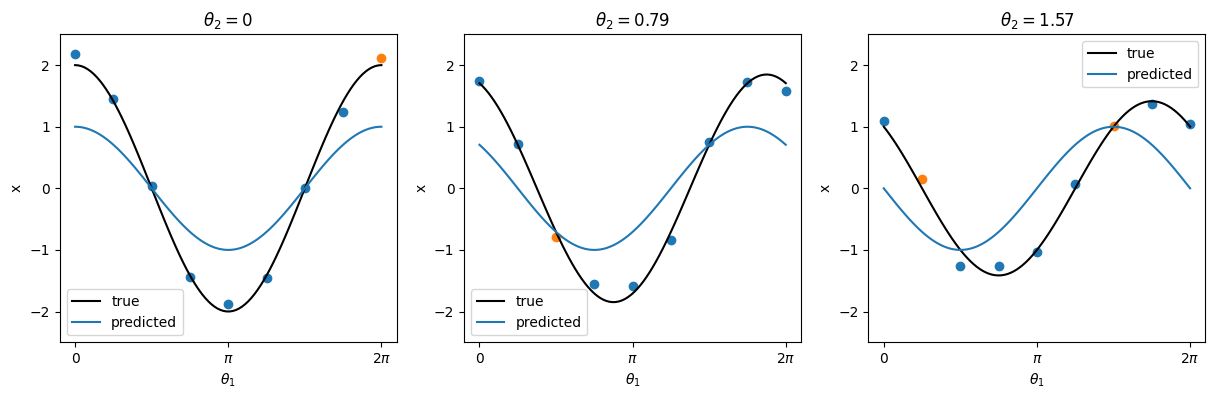

In [25]:
from utils import display_function
display_function(lambda theta_1, theta_2: np.cos(theta_1 + theta_2), train_inputs, train_outputs, test_inputs, test_outputs, ood_inputs, ood_outputs, pos_x)

## 3. Algorithmes de programmation génétique

Pour commencer, nous définissons quelques fonctions qui seront utilisées dans vos algorithmes de programmation génétiques:

- La première fonction `ru` est appelée lorsqu'on créé un nouveau noeud de type "constante" pour échantilloner une valeur à donner à cette constante. Ici, on propose d'utiliser une loi uniforme sur l'intervalle $[-1, 1]$.
- La deuxième fonction `mse`, pour "Mean Squarred Error", sert à calculer l'erreur entre les prédictions $y'=f(x)$ et le valeurs cibles de dataset $y$.

In [9]:
def ru():
    # Fonction utilisée pour échantillonner les valeurs des constantes éphémères
    return random.uniform(-1, 1)


def mse(func, inputs, outputs):
    # Erreur quadratique moyenne
    mse = np.mean((func(inputs[:, 0], inputs[:, 1]) - outputs)**2)
    # On ajoute un petit bruit pour éviter les égalités exactes
    noise = 1e-5 * np.random.randn()
    return  mse + noise

### 3.1. Primitive set

Un algorithme génétique a besoin d'un ensemble de primitives dans lequel il pourra piocher pour l'initialisation ou la mutation des individus. Dans notre cas, l'ensemble de primitives va contenir les différents opérateurs qui peuvent apparaîte dans les arbres d'expression (addition, multiplication, cosinus, etc.).

Nous allons utiliser les primitives suivantes:
- Opérateurs binaires:
    - L'addition (`operator.add` avec le module `operator`)
    - La soustraction (`operator.sub`)
    - La multiplication (`operator.mul`)
- Opérateurs unaires:
    - La fonction cosinus (via `numpy` pour fonctionner sur des `np.array`)
    - La fonction sinus (via `numpy` également)
- Noeuds terminaux:
    - Les variables $\theta_1$ et $\theta_2$
    - Des constantes (dont la valeur est tirée au sort avec la fonction `ru` définie précédemment)
    - Constante 0


#### Question 1.

Complétez la cellule suivant pour ajouter les primitives à l'ensemble de primitives.

In [10]:
# Initialisation de l'ensemble de primitives pour la programmation génétique
pset = gp.PrimitiveSet("MAIN", 2)

# Ajout des opérateurs binaires
pset.addPrimitive(operator.add, 2)
pset.addPrimitive(operator.sub, 2)
pset.addPrimitive(operator.mul, 2)

# Ajout des opérateurs unaires
pset.addPrimitive(np.cos, 1)
pset.addPrimitive(np.sin, 1)

# Ajout des constantes éphémères
pset.addEphemeralConstant("cst", ru)
pset.addTerminal(0)

### 3.2. Approche élitiste

Nous allons commencer par une version élitiste de la programmation génétique.

On définit premièrement une fitness à minimiser et les individus dans le creator. On pourra noter que les individus ne sont plus des listes de float comme dans le TME précédent, mais sont maintenant des instances de `gp.PrimitiveTree`, qui est une classe fournie par DEAP pour manipuler des arbres.

On définit dans la cellule suivante une toolbox pour la programmation génétique. Cette toolbox contient:
- une fonction pour générer des arbres d'expression aléatoires
- une fonction pour compiler un arbre d'expression en fonction exécutable en Python
- une fonction pour générer des sous-arbres d'expression utilisés par l'opérateur de mutation
- un opérateur de mutation qui remplace un noeud aléatoirement choisi par un sous-arbre aléatoire
- un opérateur de croisement qui croise deux arbres d'expression parents en un point

Enfin, pour que les arbres d'expression ne grandissent pas à des tailles démesurées, on ajoute deux décorateurs aux opérateurs de mutation et de croisement qui limitent la taille des arbres d'expressions générés. Dans ce TME, on propose de se limiter à une profondeur d'arbre de 6.

In [11]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMin)

In [12]:
toolbox = base.Toolbox()

toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=4)
toolbox.register("compile", gp.compile, pset=pset)

toolbox.register("mate", gp.cxOnePoint)
toolbox.register("expr_mut", gp.genFull, min_=0, max_=2)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)

toolbox.decorate("mate", gp.staticLimit(
    key=operator.attrgetter("height"), max_value=6))
toolbox.decorate("mutate", gp.staticLimit(
    key=operator.attrgetter("height"), max_value=6))

La fonction d'évaluation que nous allons utiliser dans le cas mono-objectif est définie ci-dessous:

In [13]:
def eval_sr_mono(individual, inputs, outputs):

    # Compile l'arbre d'expression en fonction Python
    func = toolbox.compile(expr=individual)

    # Calcule l'erreur quadratique moyenne entre les prédictions du modèle et les sorties attendues
    return mse(func, inputs, outputs),

Dans tout ce TME, on utilisera les hyperparamètres suivants pour la probabilité de croisement et de mutation.

In [14]:
cxpb = 0.7
mutpb = 0.3

#### Question 2.

Compléter la fonction `sr_elitist` implémentant un algorithme de programmation génétique avec sélection élitiste (comme dans le TME précédent).

Pour simplifier l'implémentation, vous pouvez utiliser directement `algorithms.eaMuPlusLambda` tel que fourni par DEAP.
Consultez la documentation pour utiliser correctement cette fonction.

In [19]:
def sr_elitist(nb_gen, mu, lambda_, train_inputs, train_outputs, verbose=True):
    """
    Régression symbolique version élitiste
        :param nb_gen: nombre de générations
        :param mu: taille de la population
        :param lambda_: nombre d'individus générés à chaque génération
        :param train_inputs: données d'entraînement
        :param train_outputs: données d'entraînements
        :param verbose: affichage de la progression
    """
    random.seed()

    # Statistiques à enregistrer pendant l'évolution
    # En plus de la fitness, on enregistre la taille et la hauteur des individus
    stats_fit = tools.Statistics(lambda ind: ind.fitness.values)
    stats_size = tools.Statistics(len)
    stats_height = tools.Statistics(lambda ind: ind.height)
    mstats = tools.MultiStatistics(
        fitness=stats_fit, size=stats_size, height=stats_height)
    mstats.register("avg", np.mean)
    mstats.register("min", np.min)

    # Fonctions nécessaires à ajouter à la toolbox
    toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", eval_sr_mono, inputs=train_inputs, outputs=train_outputs)
    toolbox.register("select", tools.selTournament, tournsize=3)

    # Initialisation de la population et du hall of fame
    pop = toolbox.population(n=mu)
    hof = tools.HallOfFame(1)

    # Algorithme eaMuPlusLambda pour l'évolution de la population
    pop, log = algorithms.eaMuPlusLambda(pop, toolbox, mu, lambda_, cxpb, mutpb, nb_gen, stats=mstats, halloffame=hof, verbose=verbose)

    return pop, log, hof

Les cellules suivantes vous permettent de tester votre implémentation et d'afficher l'évolution de l'erreur et de la taille des individus au cours du temps. Il vous est recommandé d'utiliser des populations d'au moins 200 individus, évoluées sur au moins 200 générations. Selon vos moyens de calculs, n'hésitez pas à tester votre algorithme sur moins de générations ou des populations plus petites. Dans cette partie, le but est juste de tester votre implémentation, pas d'analyser des résultats.

In [22]:
nb_gen = 500
pop_size = 200

pop, log, hof = sr_elitist(
    nb_gen, pop_size, pop_size, train_inputs, train_outputs, verbose=True)

   	      	               fitness                	            height            	             size             
   	      	--------------------------------------	------------------------------	------------------------------
gen	nevals	avg    	gen	min     	nevals	avg 	gen	min	nevals	avg 	gen	min	nevals
0  	200   	202.116	0  	0.473788	200   	2.13	0  	1  	200   	5.53	0  	2  	200   
1  	200   	1.78521	1  	0.473769	200   	2.185	1  	0  	200   	5.28	1  	1  	200   
2  	200   	1.05803	2  	0.473777	200   	2.2  	2  	0  	200   	5.235	2  	1  	200   
3  	200   	0.870465	3  	0.473671	200   	2.085	3  	0  	200   	4.9  	3  	1  	200   
4  	200   	0.689623	4  	0.375709	200   	1.98 	4  	0  	200   	4.25 	4  	1  	200   
5  	200   	0.547544	5  	0.375709	200   	1.765	5  	0  	200   	3.475	5  	1  	200   
6  	200   	0.513081	6  	0.375709	200   	1.855	6  	1  	200   	3.51 	6  	2  	200   
7  	200   	0.481694	7  	0.375706	200   	2.065	7  	1  	200   	3.895	7  	2  	200   
8  	200   	0.459631	8  	0.321882	200   	2.63 	8

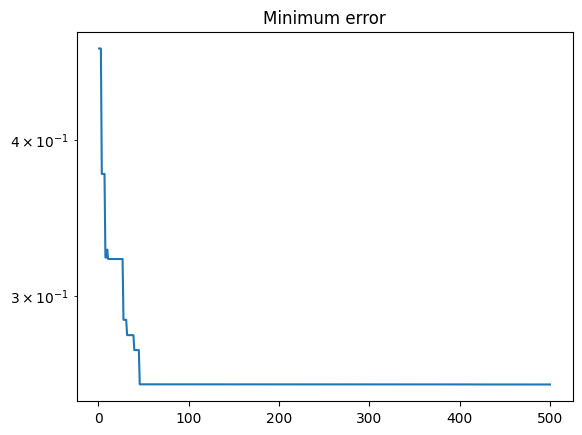

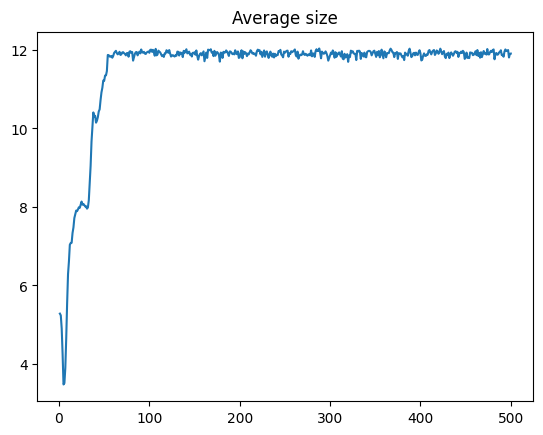

In [23]:
gen = log.select("gen")

# Affichage de l'évolution de la meilleure fitness par génération
min_error = log.chapters['fitness'].select("min")
plt.figure()
plt.plot(gen[1:], min_error[1:], label="min")
plt.yscale("log")
plt.title("Minimum error")
plt.show()

# Affichage de l'évolution de la taille moyenne des arbres d'expression
avg_size = log.chapters['size'].select("avg")
plt.figure()
plt.plot(gen[1:], avg_size[1:])
plt.title("Average size")
plt.show()

Vous pouvez également utiliser la cellule suivante pour afficher le graphe et l'allure de la meilleure fonction trouvée par votre algorithme, et calculer son erreur sur les données d'entraînement et de test:

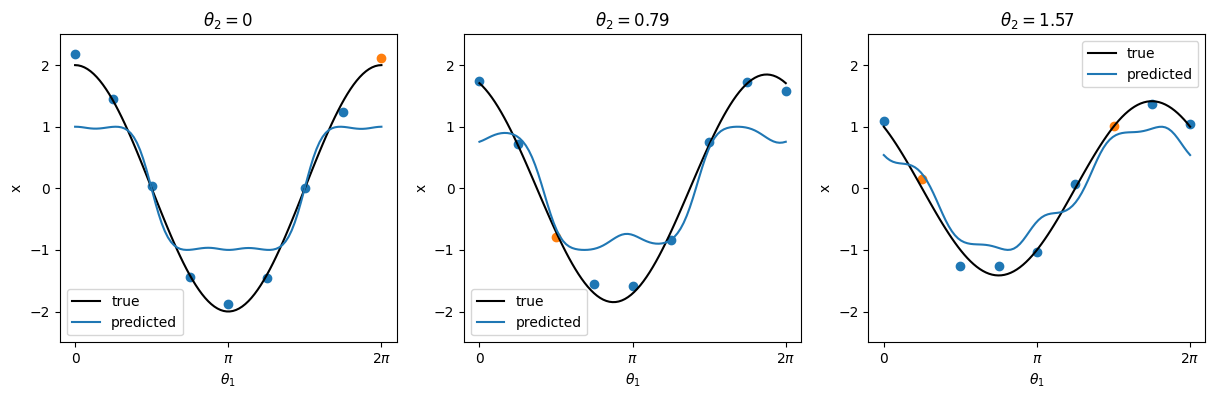

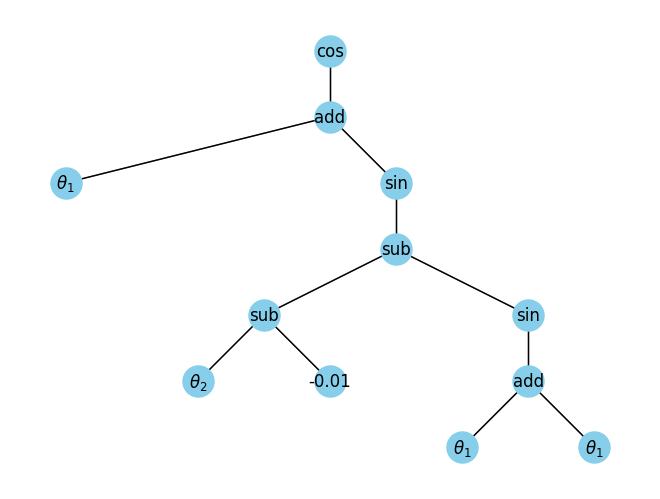

MSE on training set: 0.2546046092805624
MSE on test set: 0.2905482603584096


In [26]:
# Récupération du meilleur individu
ind = hof[0]

# Compilation de la fonction associée à l'individu
func = gp.compile(expr=ind, pset=pset)

# Affichage l'allure de la fonction sur les données
display_function(func, train_inputs, train_outputs, test_inputs, test_outputs, ood_inputs, ood_outputs, pos_x)

# Affichage l'arbre symbolique
plot_symbolic_tree(ind)

# Affichage l'erreur sur les données d'entraînement et de test
print("MSE on training set:", mse(func, train_inputs, train_outputs))
print("MSE on test set:", mse(func, test_inputs, test_outputs))

### 3.3. Approche par double tournoi

#### Question 3. 

Complétez l'implémentation de la fonction `sr_double_tournament` en vous inspirant de la question précédente. 

Cette fois, la sélection devra se faire par un double tournoi `selDoubleTournament`:
- le premier tournoi fait intervenir deux individus, et sélectionne l'individu dont l'arbre d'expression est le plus petit avec une probabilité `parsimony_size / 2`
- le deuxième tournoi fait intervenir `fitness_size` individus et sélectionne l'individu avec la meilleure fitness. 

In [36]:
def sr_double_tournament(nb_gen, mu, lambda_, train_inputs, train_outputs, verbose=True, parsimony_size=1.5):
    """
    Régression symbolique version élitiste
        :param nb_gen: nombre de générations
        :param mu: taille de la population
        :param lambda_: nombre d'individus générés à chaque génération
        :param train_inputs: données d'entraînement
        :param train_outputs: données d'entraînements
        :param verbose: affichage de la progression
        :param parsimony_size: paramètre utilisé lors du second tournoi
    """
    random.seed()

    # Statistiques
    stats_fit = tools.Statistics(lambda ind: ind.fitness.values)
    stats_size = tools.Statistics(len)
    stats_height = tools.Statistics(lambda ind: ind.height)
    mstats = tools.MultiStatistics(
        fitness=stats_fit, size=stats_size, height=stats_height)
    mstats.register("avg", np.mean)
    mstats.register("min", np.min)

    # Enregistrez les différents opérateurs que vous utiliserez dans la suite.
    toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", eval_sr_mono, inputs=train_inputs, outputs=train_outputs)
    toolbox.register("select", tools.selDoubleTournament, fitness_size=3, parsimony_size=parsimony_size, fitness_first=True)

    # Initialisation de la population et du hall of fame
    pop = toolbox.population(n=mu)
    hof = tools.HallOfFame(1)

    # Algorithme eaMuPlusLambda pour l'évolution de la population
    pop, log = algorithms.eaMuPlusLambda(pop, toolbox, mu, lambda_, cxpb, mutpb, nb_gen, stats=mstats, halloffame=hof, verbose=verbose)

    return pop, log, hof

In [37]:
nb_gen = 500
pop_size = 200

pop, log, hof = sr_double_tournament(
    nb_gen, pop_size, pop_size, train_inputs, train_outputs, verbose=True, parsimony_size=1.4)

   	      	               fitness                	            height            	             size             
   	      	--------------------------------------	------------------------------	------------------------------
gen	nevals	avg    	gen	min     	nevals	avg 	gen	min	nevals	avg  	gen	min	nevals
0  	200   	52.9143	0  	0.473783	200   	2.09	0  	1  	200   	5.905	0  	2  	200   
1  	200   	1.85644	1  	0.47313 	200   	1.89	1  	0  	200   	4.47 	1  	1  	200   
2  	200   	1.05148	2  	0.47313 	200   	1.595	2  	0  	200   	3.7  	2  	1  	200   
3  	200   	0.891116	3  	0.342838	200   	1.435	3  	0  	200   	3.23 	3  	1  	200   
4  	200   	0.73816 	4  	0.342838	200   	1.375	4  	0  	200   	2.885	4  	1  	200   
5  	200   	0.580573	5  	0.342821	200   	1.265	5  	0  	200   	2.615	5  	1  	200   
6  	200   	0.497247	6  	0.47313 	200   	1.155	6  	0  	200   	2.325	6  	1  	200   
7  	200   	0.480363	7  	0.47313 	200   	1.125	7  	1  	200   	2.25 	7  	2  	200   
8  	200   	0.473654	8  	0.47313 	200   	1.19 

Les cellules suivantes vous permettent de tester votre implémentation et d'afficher l'évolution de l'erreur et de la taille des individus au cours du temps. Il vous est recommandé d'utiliser des populations d'au moins 200 individus, évoluées sur au moins 200 générations. Selon vos moyens de calculs, n'hésitez pas à tester votre algorithme sur moins de générations ou des populations plus petites. Dans cette partie, le but est juste de tester votre implémentation, pas d'analyser des résultats.

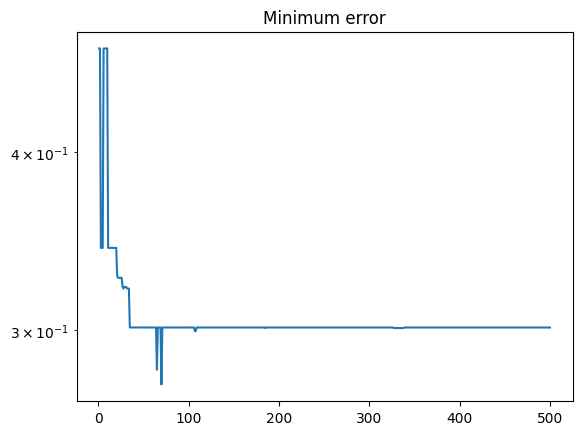

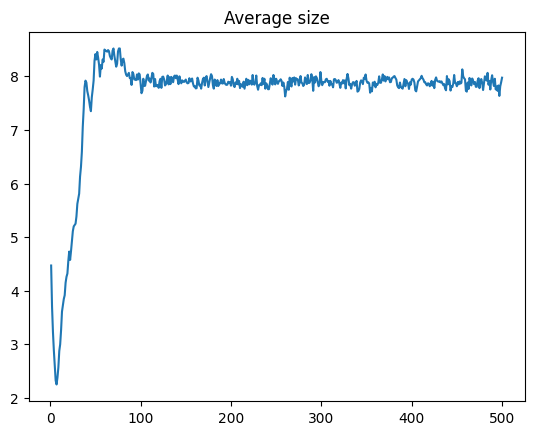

In [39]:
gen = log.select("gen")

# Affichage de l'évolution de la meilleure fitness par génération
min_error = log.chapters['fitness'].select("min")
plt.figure()
plt.plot(gen[1:], min_error[1:], label="min")
plt.yscale("log")
plt.title("Minimum error")
plt.show()

# Affichage de l'évolution de la taille moyenne des arbres d'expression
avg_size = log.chapters['size'].select("avg")
plt.figure()
plt.plot(gen[1:], avg_size[1:])
plt.title("Average size")
plt.show()

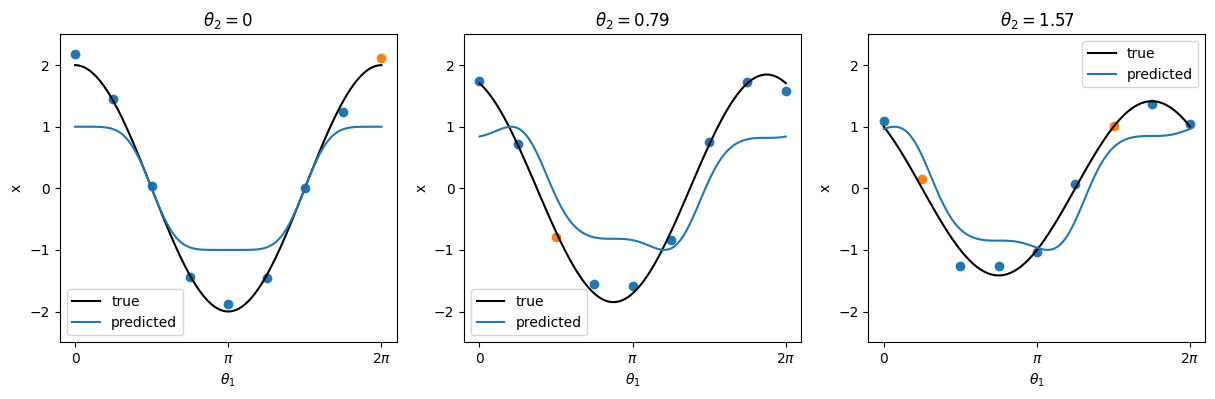

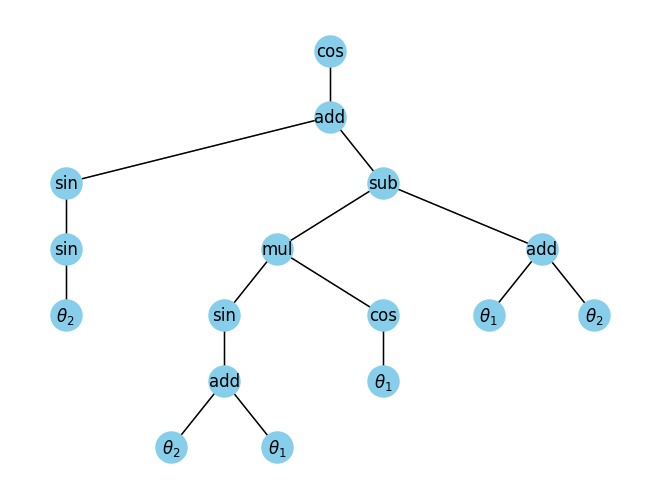

MSE on training set: 0.2749600308209129
MSE on test set: 0.48292114251703944


In [40]:
# Récupération du meilleur individu
ind = hof[0]

# Compilation de la fonction associée à l'individu
func = gp.compile(expr=ind, pset=pset)

# Affichage l'allure de la fonction sur les données
display_function(func, train_inputs, train_outputs, test_inputs, test_outputs, ood_inputs, ood_outputs, pos_x)

# Affichage l'arbre symbolique
plot_symbolic_tree(ind)

# Affichage l'erreur sur les données d'entraînement et de test
print("MSE on training set:", mse(func, train_inputs, train_outputs))
print("MSE on test set:", mse(func, test_inputs, test_outputs))

### 3.4. Approche multi-objectifs

Dnas la version multi-objectifs, on va utiliser NSGA2 pour optimiser à la fois l'erreur de prédiction et la taille des individus. On est sur un problème de double minimisation, pour lequel on défini les classes suivantes dans le creator:

In [41]:
creator.create("FitnessMinMin", base.Fitness, weights=(-1.0, -1.0))  # double minimisation
creator.create("Individual2", gp.PrimitiveTree, fitness=creator.FitnessMinMin)

#### Question 5.

En vous inspirant de la fonction `eval_sr_mono`, implémentez la fonction `eval_sr_multi` qui sera utilisée par NSGA2.

In [42]:
def eval_sr_multi(individual, inputs, outputs):
    func = toolbox.compile(expr=individual)
    error = mse(func, inputs, outputs)
    complexity = len(individual)

    return error, complexity

#### Question 6.

Complétez la fonction suivante implémentant l'algorithme NSGA2.

In [54]:
def sr_nsga2(nb_gen, mu, lambda_, train_inputs, train_outputs, verbose=True):
    """
    Régression symbolique version élitiste
        :param nb_gen: nombre de générations
        :param mu: taille de la population
        :param lambda_: nombre d'individus générés à chaque génération
        :param train_inputs: données d'entraînement
        :param train_outputs: données d'entraînements
        :param verbose: affichage de la progression
    """
    random.seed()

    # Statistiques
    stats_fit = tools.Statistics(lambda ind: ind.fitness.values)
    stats_size = tools.Statistics(lambda ind: len(ind))
    stats_height = tools.Statistics(lambda ind: ind.height)
    mstats = tools.MultiStatistics(
        fitness=stats_fit, size=stats_size, height=stats_height)
    mstats.register("avg", np.mean)
    mstats.register("min", np.min)

    # Remplissage de la toolbox
    toolbox.register("individual", tools.initIterate, creator.Individual2, toolbox.expr)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", eval_sr_multi, inputs=train_inputs, outputs=train_outputs)
    toolbox.register("select", tools.selNSGA2)

    pop = toolbox.population(n=mu)
    pareto = tools.ParetoFront()

    # Algorithme eaMuPlusLambda pour l'évolution de la population
    pop, log = algorithms.eaMuPlusLambda(pop, toolbox, mu, lambda_, cxpb, mutpb, nb_gen, stats=mstats, halloffame=pareto, verbose=verbose)


    return pop, log, pareto

Les cellules suivantes vous permettent de tester votre implémentation et d'afficher l'évolution de l'erreur et de la taille des individus au cours du temps. Il vous est recommandé d'utiliser des populations d'au moins 200 individus, évoluées sur au moins 200 générations. Selon vos moyens de calculs, n'hésitez pas à tester votre algorithme sur moins de générations ou des populations plus petites. Dans cette partie, le but est juste de tester votre implémentation, pas d'analyser des résultats.

In [59]:
nb_gen = 500
pop_size = 200

pop, log, pareto = sr_nsga2(
    nb_gen, pop_size, pop_size, train_inputs, train_outputs, verbose=True)

   	      	               fitness                	            height            	             size             
   	      	--------------------------------------	------------------------------	------------------------------
gen	nevals	avg    	gen	min     	nevals	avg 	gen	min	nevals	avg 	gen	min	nevals
0  	200   	35.5684	0  	0.473769	200   	2.21	0  	1  	200   	6.65	0  	2  	200   
1  	200   	3.50158	1  	0.473769	200   	2.1 	1  	0  	200   	5.495	1  	1  	200   
2  	200   	3.83811	2  	0.473769	200   	2.12	2  	0  	200   	6.045	2  	1  	200   
3  	200   	3.71324	3  	0.473769	200   	1.95	3  	0  	200   	5.335	3  	1  	200   
4  	200   	3.30451	4  	0.473758	200   	1.55	4  	0  	200   	4.14 	4  	1  	200   
5  	200   	2.63261	5  	0.473758	200   	1.195	5  	0  	200   	3.275	5  	1  	200   
6  	200   	1.63363	6  	0.466069	200   	0.87 	6  	0  	200   	2.43 	6  	1  	200   
7  	200   	1.37276	7  	0.466069	200   	0.675	7  	0  	200   	1.935	7  	1  	200   
8  	200   	1.35344	8  	0.466069	200   	0.66 	8  	0  	20

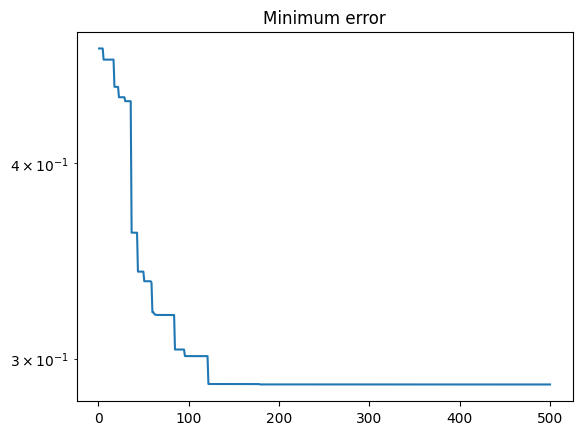

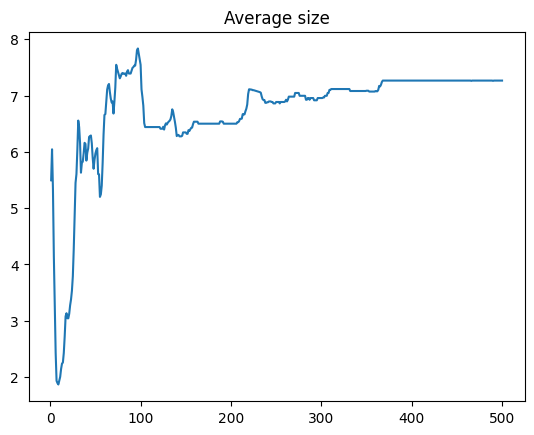

In [60]:
gen = log.select("gen")

# Affichage de l'évolution de la meilleure fitness par génération
min_error = log.chapters['fitness'].select("min")
plt.figure()
plt.plot(gen[1:], min_error[1:], label="min")
plt.yscale("log")
plt.title("Minimum error")
plt.show()

# Affichage de l'évolution de la taille moyenne des arbres d'expression
avg_size = log.chapters['size'].select("avg")
plt.figure()
plt.plot(gen[1:], avg_size[1:])
plt.title("Average size")
plt.show()

HOF 0, len=13
Error on the training dataset: 0.288997
Error on the testing dataset: 0.387135


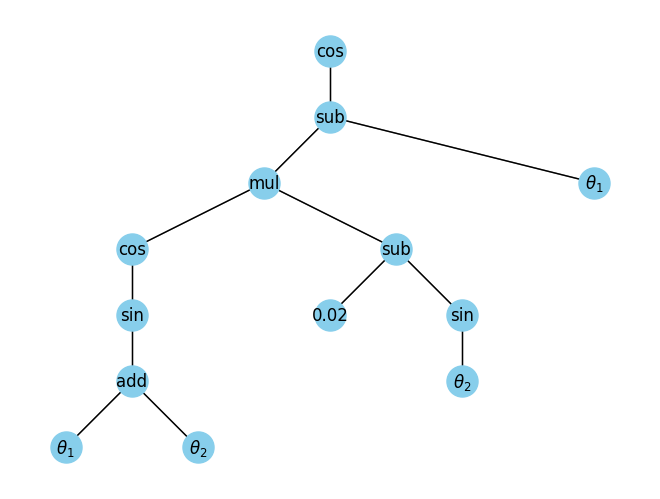

HOF 1, len=12
Error on the training dataset: 0.300432
Error on the testing dataset: 0.553721


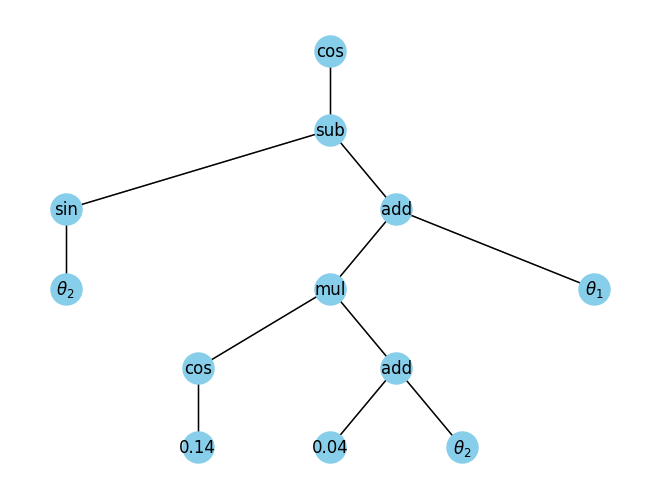

HOF 2, len=10
Error on the training dataset: 0.300594
Error on the testing dataset: 0.555107


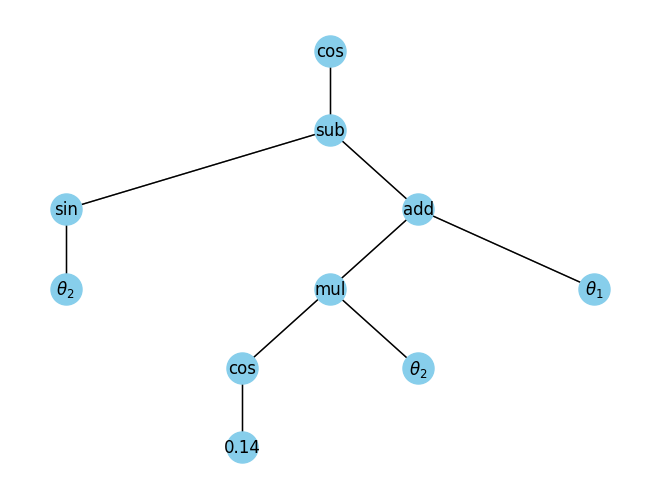

HOF 3, len=9
Error on the training dataset: 0.300633
Error on the testing dataset: 0.555968


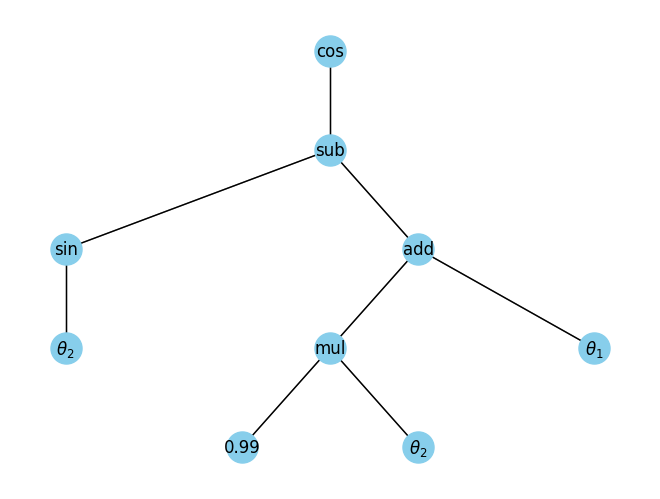

HOF 4, len=8
Error on the training dataset: 0.301489
Error on the testing dataset: 0.538136


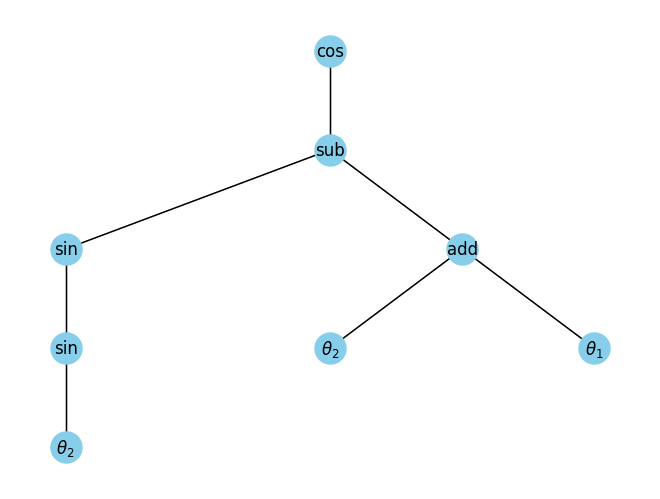

HOF 5, len=7
Error on the training dataset: 0.301597
Error on the testing dataset: 0.560305


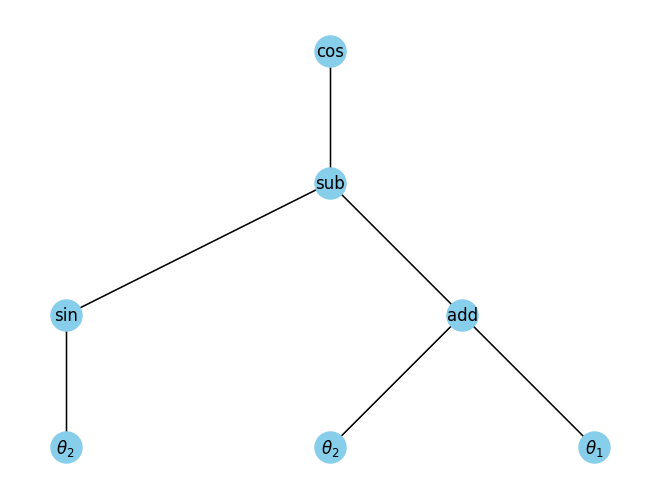

HOF 6, len=6
Error on the training dataset: 0.452595
Error on the testing dataset: 0.588836


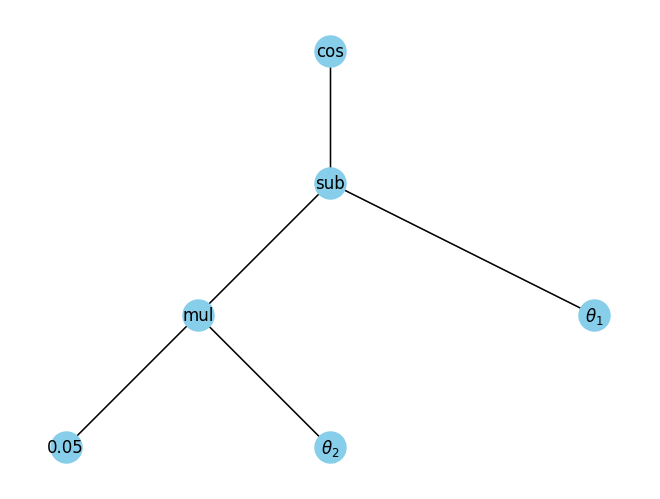

HOF 7, len=4
Error on the training dataset: 0.473036
Error on the testing dataset: 0.607790


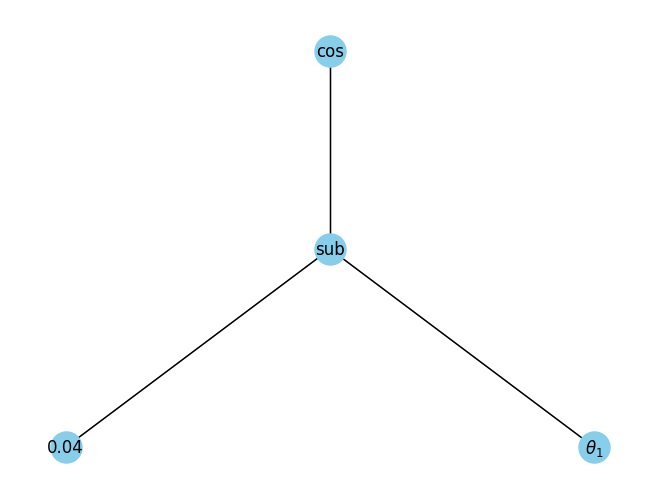

HOF 8, len=2
Error on the training dataset: 0.473798
Error on the testing dataset: 0.605646


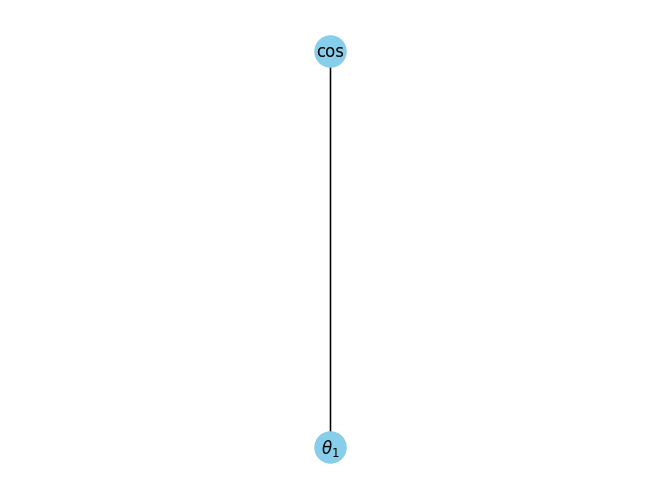

HOF 9, len=1
Error on the training dataset: 1.215042
Error on the testing dataset: 0.991503


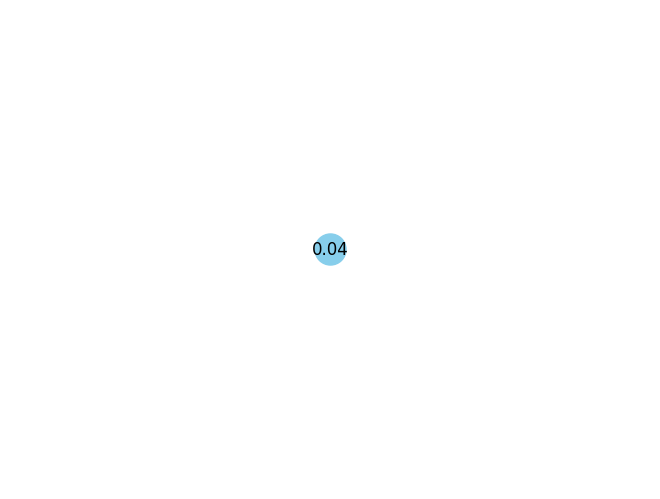

In [61]:
# Affichage du front de pareto
for i, ind in enumerate(pareto):
    print("==================================================================================")
    print("HOF %d, len=%d" % (i, len(ind)))
    ind_func = gp.compile(ind, pset=pset)
    print("Error on the training dataset: %f" %
          mse(ind_func, train_inputs, train_outputs))
    print("Error on the testing dataset: %f" %
          mse(ind_func, test_inputs, test_outputs))
    plot_symbolic_tree(ind)

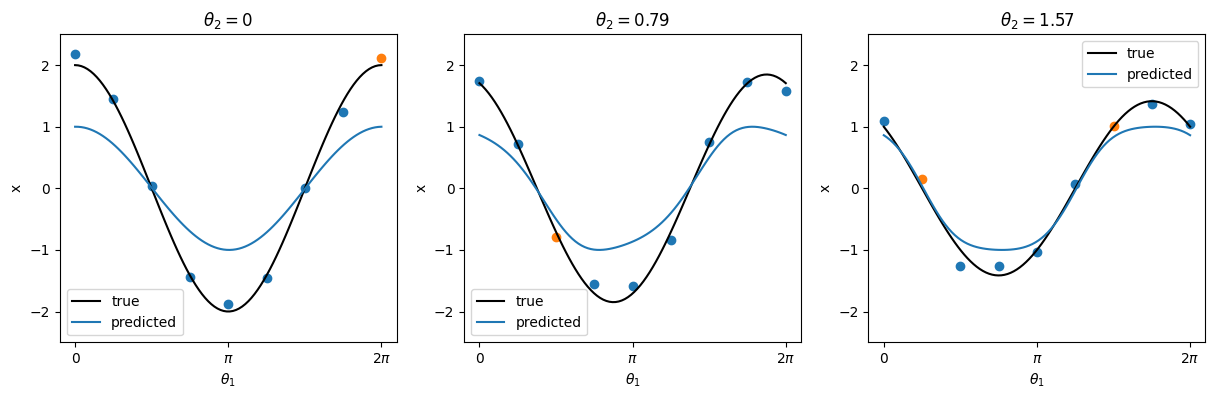

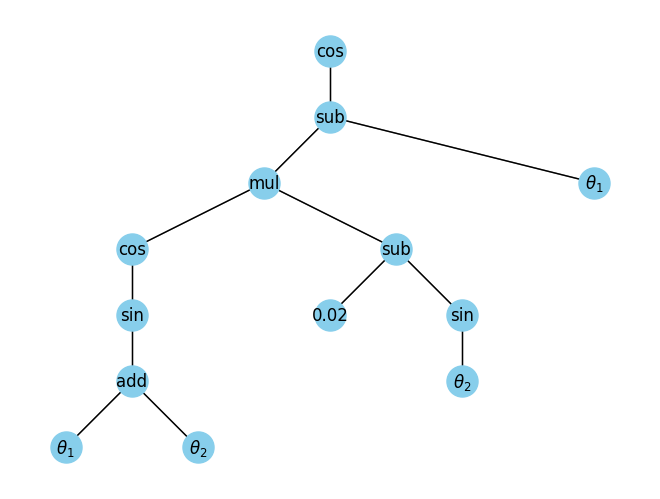

MSE on training set: 0.28899376657966724
MSE on test set: 0.3871341316670411


In [62]:
# Récupération du meilleur individu
ind = pareto[0]

# Compilation de la fonction associée à l'individu
func = gp.compile(expr=ind, pset=pset)

# Affichage l'allure de la fonction sur les données
display_function(func, train_inputs, train_outputs, test_inputs, test_outputs, ood_inputs, ood_outputs, pos_x)

# Affichage l'arbre symbolique
plot_symbolic_tree(ind)

# Affichage l'erreur sur les données d'entraînement et de test
print("MSE on training set:", mse(func, train_inputs, train_outputs))
print("MSE on test set:", mse(func, test_inputs, test_outputs))

## 4. Analyses

### 4.1. Premières comparaisons

#### Question 7.

Lancez chaque algorithme plusieurs fois (au moins 5 seeds), avec au moins 200 générations et des populations d'au moins 200 individus.

Utilisez les cellules suivante pour tracer:
- L'évolution de la **meilleure fitness** de la population en fonction de la génération. 
- L'évolution de la **taille moyenne** des individus de la population en fonction de la génération. 

Vous devrez aussi calculer le temps moyen (sur les 5 seeds) d'exécution de chaque algorithme. Vous pouvez utiliser le module `time`.

In [63]:
from time import time

seeds = 5

nb_gen = 500
pop_size = 200

size_elitist = np.zeros((seeds, nb_gen+1))
train_error_elitist = np.zeros((seeds, nb_gen+1))
test_error_elitist = np.zeros(seeds)
times_elitist = np.zeros(seeds)

size_double_tournament = np.zeros((seeds, nb_gen+1))
train_error_double_tournament = np.zeros((seeds, nb_gen+1))
test_error_double_tournament = np.zeros(seeds)
times_double_tournament = np.zeros(seeds)

size_nsga2 = np.zeros((seeds, nb_gen+1))
train_error_nsga2 = np.zeros((seeds, nb_gen+1))
test_error_nsga2 = np.zeros(seeds)
times_nsga2 = np.zeros(seeds)

for s in range(seeds):

    print("Seed %d/%d" % (s+1, seeds))

    start = time()
    pop, log, hof = sr_elitist(nb_gen, pop_size, pop_size, train_inputs, train_outputs, verbose=False)
    size_elitist[s] = log.chapters['size'].select("avg")
    train_error_elitist[s] = log.chapters['fitness'].select("min")

    ind = hof[0]
    func = gp.compile(expr=ind, pset=pset)
    test_error_elitist[s] = mse(func, test_inputs, test_outputs)
    times_elitist[s] = time() - start

    start = time()
    pop, log, hof = sr_double_tournament(nb_gen, pop_size, pop_size, train_inputs, train_outputs, verbose=False, parsimony_size=1.4)
    size_double_tournament[s] = log.chapters['size'].select("avg")
    train_error_double_tournament[s] = log.chapters['fitness'].select("min")

    ind = hof[0]
    func = gp.compile(expr=ind, pset=pset)
    test_error_double_tournament[s] = mse(func, test_inputs, test_outputs)
    times_double_tournament[s] = time() - start

    start = time()
    pop, log, pareto = sr_nsga2(nb_gen, pop_size, pop_size, train_inputs, train_outputs, verbose=False)
    size_nsga2[s] = log.chapters['size'].select("avg")

    train_error_nsga2[s] = log.chapters['fitness'].select("min")
    ind = pareto[0]
    func = gp.compile(expr=ind, pset=pset)
    test_error_nsga2[s] = mse(func, test_inputs, test_outputs)
    times_nsga2[s] = time() - start

Seed 1/5
Seed 2/5
Seed 3/5
Seed 4/5
Seed 5/5


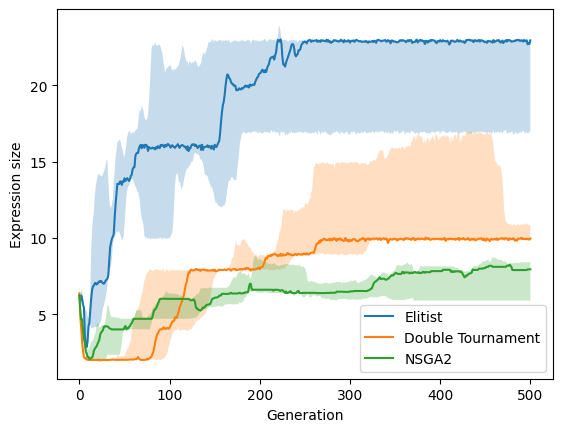

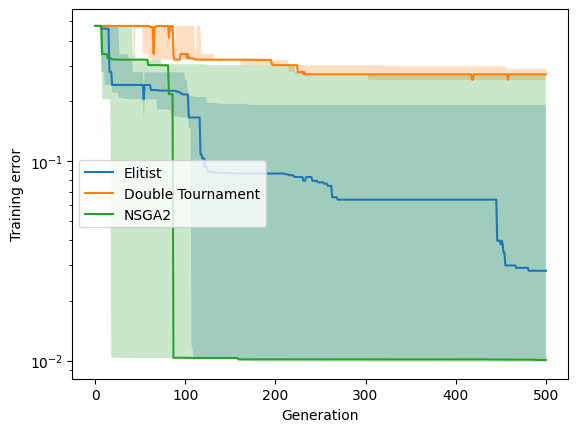

Average time elitist: 10.283438777923584
Average time double tournament: 7.473941373825073
Average time nsga2: 39.5127495765686
Final test error elitist: 
	median 0.056
	25th percentile 0.009
	75th percentile 0.210
Final test error double tournament: 
	median 0.291
	25th percentile 0.291
	75th percentile 0.329
Final test error nsga2: 
	median 0.010
	25th percentile 0.009
	75th percentile 0.447


In [64]:
first_size_elitist = np.quantile(size_elitist, 0.25, axis=0)
third_size_elitist = np.quantile(size_elitist, 0.75, axis=0)
median_size_elitist = np.median(size_elitist, axis=0)

first_size_double_tournament = np.quantile(
    size_double_tournament, 0.25, axis=0)
third_size_double_tournament = np.quantile(
    size_double_tournament, 0.75, axis=0)
median_size_double_tournament = np.median(size_double_tournament, axis=0)

first_size_nsga2 = np.quantile(size_nsga2, 0.25, axis=0)
third_size_nsga2 = np.quantile(size_nsga2, 0.75, axis=0)
median_size_nsga2 = np.median(size_nsga2, axis=0)

plt.figure()
plt.plot(median_size_elitist, label="Elitist")
plt.fill_between(range(nb_gen+1), first_size_elitist,
                 third_size_elitist, alpha=0.25, linewidth=0)
plt.plot(median_size_double_tournament, label="Double Tournament")
plt.fill_between(range(nb_gen+1), first_size_double_tournament,
                 third_size_double_tournament, alpha=0.25, linewidth=0)
plt.plot(median_size_nsga2, label="NSGA2")
plt.fill_between(range(nb_gen+1), first_size_nsga2,
                 third_size_nsga2, alpha=0.25, linewidth=0)
plt.legend()
plt.xlabel("Generation")
plt.ylabel("Expression size")
plt.show()

first_train_error_elitist = np.quantile(train_error_elitist, 0.25, axis=0)
third_train_error_elitist = np.quantile(train_error_elitist, 0.75, axis=0)
median_train_error_elitist = np.median(train_error_elitist, axis=0)

first_train_error_double_tournament = np.quantile(
    train_error_double_tournament, 0.25, axis=0)
third_train_error_double_tournament = np.quantile(
    train_error_double_tournament, 0.75, axis=0)
median_train_error_double_tournament = np.median(
    train_error_double_tournament, axis=0)

first_train_error_nsga2 = np.quantile(train_error_nsga2, 0.25, axis=0)
third_train_error_nsga2 = np.quantile(train_error_nsga2, 0.75, axis=0)
median_train_error_nsga2 = np.median(train_error_nsga2, axis=0)


plt.figure()
plt.plot(median_train_error_elitist, label="Elitist")
plt.fill_between(range(nb_gen+1), first_train_error_elitist,
                 third_train_error_elitist, alpha=0.25, linewidth=0)
plt.plot(median_train_error_double_tournament, label="Double Tournament")
plt.fill_between(range(nb_gen+1), first_train_error_double_tournament,
                 third_train_error_double_tournament, alpha=0.25, linewidth=0)
plt.plot(median_train_error_nsga2, label="NSGA2")
plt.fill_between(range(nb_gen+1), first_train_error_nsga2,
                 third_train_error_nsga2, alpha=0.25, linewidth=0)
plt.yscale("log")
plt.legend()
plt.xlabel("Generation")
plt.ylabel("Training error")
plt.show()

first_test_error_elitist = np.quantile(test_error_elitist, 0.25, axis=0)
third_test_error_elitist = np.quantile(test_error_elitist, 0.75, axis=0)
median_test_error_elitist = np.median(test_error_elitist, axis=0)

first_test_error_double_tournament = np.quantile(
    test_error_double_tournament, 0.25, axis=0)
third_test_error_double_tournament = np.quantile(
    test_error_double_tournament, 0.75, axis=0)
median_test_error_double_tournament = np.median(
    test_error_double_tournament, axis=0)

first_test_error_nsga2 = np.quantile(test_error_nsga2, 0.25, axis=0)
third_test_error_nsga2 = np.quantile(test_error_nsga2, 0.75, axis=0)
median_test_error_nsga2 = np.median(test_error_nsga2, axis=0)

print("Average time elitist:", np.mean(times_elitist))
print("Average time double tournament:", np.mean(times_double_tournament))
print("Average time nsga2:", np.mean(times_nsga2))

print("==========================================================")

print(
    f"Final test error elitist: \n\tmedian {median_test_error_elitist:.3f}\n\t25th percentile {first_test_error_elitist:.3f}\n\t75th percentile {third_test_error_elitist:.3f}")
print(
    f"Final test error double tournament: \n\tmedian {median_test_error_double_tournament:.3f}\n\t25th percentile {first_test_error_double_tournament:.3f}\n\t75th percentile {third_test_error_double_tournament:.3f}")
print(
    f"Final test error nsga2: \n\tmedian {median_test_error_nsga2:.3f}\n\t25th percentile {first_test_error_nsga2:.3f}\n\t75th percentile {third_test_error_nsga2:.3f}")

#### Question 8.

1) Quelle est la fitness théorique que l'on devrait obtenir si on trouve la bonne expression symbolique, en considérant l'amplitude de bruit appliqué sur les données ?
La meilleure fitness théorique (MSE) est 0,01, car le bruit ajouté a une amplitude de 0,1 (variance = 0,01).

2) Décrivrez les graphiques obtenus.
"Élitiste" a une erreur médiane 0,05, assez variable.
"Double tournoi" a une erreur élevée, stable, temps d’exécution le plus court.
"NSGA2" a une erreur médiane la plus faible mais grande dispersion, temps d’exécution est le plus long.
L’élitiste produit des arbres plus grands, le double tournoi et NSGA2 maintiennent des arbres plus petits.

3) Comment expliquer les différences entre les algorithmes sur l'évolution de la taille des individus ?
"Élitiste" il sélection uniquement sur la fitness, donc il a une tendance à l’augmentation de la taille.
"Double Tournament" il sélecte combinant fitness et taille parsimony, donc l'arbre est petite.
"NSGA2" il optimise multi‑objectifs sur le erreur et la taille, donc l'arbre et aussi petite. 

4) Quel algorithme est le plus rapide et le plus lent  et pourquoi d'après vous ? 
Algo "Double tournament" est le plus rapide, parce que le choix est simple, les arbres sont petits.
Algo "NSGA2" est le plus lent, car il ya le tri de Pareto, il calcul de distance de crowding, et ya évaluation multi‑objectifs.

5) Sans relancer d'expérience, pouvez vous dire quel est l'impact de la taille de la population sur le temps pris par chaque algorithme, en considérant à la fois l'évaluation et la sélection.
Le temps augmente linéairement avec la population pour tous les algos.
"Élitiste" et "double tournoi" ont la complexité quasi‑linéaire. "NSGA2" a une complexité quadratique.

### 4.2. Performance sur les données de test

Pour cette partie, vous utiliserez un jeu de données comportant moins de données d'entraînement et plus de bruit. Dans cette situation, le problème de régression symbolique est d'autant plus difficile, car une solution qui matche très bien les données d'entraînement n'est pas forcément l'expression symbolique que l'on cherche.

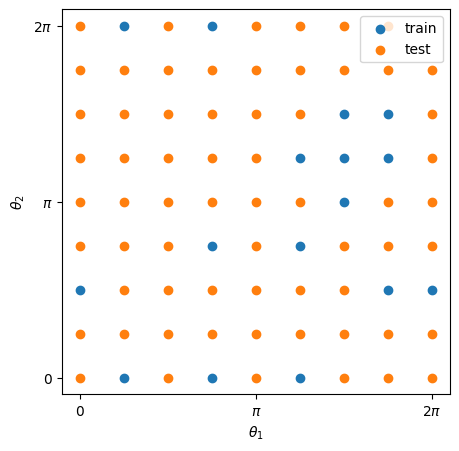

In [65]:
np.random.seed(0)

train_inputs_2, train_outputs_2, test_inputs_2, test_outputs_2, ood_inputs_2, ood_outputs_2 = generate_data(
    n_points=9, train_split=0.2, test_split=0.8, noise=0.3)

# Plot the 2D grid corresponding to the training + testing inputs, with equal aspect ratio
plt.figure(figsize=(5, 5))
plt.scatter(train_inputs_2[:, 0], train_inputs_2[:, 1], label='train')
plt.scatter(test_inputs_2[:, 0], test_inputs_2[:, 1], label='test')
plt.xticks([0, math.pi, 2*math.pi], ['0', r'$\pi$', r'$2\pi$'])
plt.yticks([0, math.pi, 2*math.pi], ['0', r'$\pi$', r'$2\pi$'])
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.axis('equal')
plt.legend()
plt.show()

#### Question 9.

Relancez plusieurs simulations avec les trois algorithmes, en calculant et sauvegardant pour chaque algorithme et chaque seed, l'erreur sur les données de test du meilleur individu (pour les algorithmes mono-objectifs), et la meilleure erreur sur les données de test parmi les individus du front de pareto (pour NSGA2).

A l'aide des cellules suivantes, tracer un graphique type "boîte à moustache" pour comparer les performances sur les données d'entraînement et les données de test à la dernière génération, pour les trois algorithmes. Votre graphique devra comporter 6 boîtes, (3 algorithmes * 2 (entraînement + test)).

In [69]:
seeds = 5
nb_gen = 500
pop_size = 200

size_elitist = np.zeros((seeds, nb_gen+1))
train_error_elitist = np.zeros((seeds, nb_gen+1))
test_error_elitist = np.zeros(seeds)

size_double_tournament = np.zeros((seeds, nb_gen+1))
train_error_double_tournament = np.zeros((seeds, nb_gen+1))
test_error_double_tournament = np.zeros(seeds)

size_nsga2 = np.zeros((seeds, nb_gen+1))
train_error_nsga2 = np.zeros((seeds, nb_gen+1))
test_error_nsga2 = np.zeros(seeds)

all_paretos = []

for s in range(seeds):
    print("Seed %d/%d" % (s+1, seeds))
    pop, log, hof = sr_elitist(nb_gen, pop_size, pop_size, train_inputs_2, train_outputs_2, verbose=False)
    size_elitist[s] = log.chapters['size'].select("avg")
    train_error_elitist[s] = log.chapters['fitness'].select("min")
    ind = hof[0]
    func = gp.compile(expr=ind, pset=pset)
    test_error_elitist[s] = mse(func, test_inputs_2, test_outputs_2)

    pop, log, hof = sr_double_tournament(nb_gen, pop_size, pop_size, train_inputs_2, train_outputs_2, verbose=False, parsimony_size=1.4)
    size_double_tournament[s] = log.chapters['size'].select("avg")
    train_error_double_tournament[s] = log.chapters['fitness'].select("min")
    ind = hof[0]
    func = gp.compile(expr=ind, pset=pset)
    test_error_double_tournament[s] = mse(func, test_inputs_2, test_outputs_2)

    pop, log, pareto = sr_nsga2(nb_gen, pop_size, pop_size, train_inputs_2, train_outputs_2, verbose=False)
    size_nsga2[s] = log.chapters['size'].select("avg")
    train_error_nsga2[s] = log.chapters['fitness'].select("min")
    current_best = float('inf')
    for ind in pareto:
        func = gp.compile(expr=ind, pset=pset)
        test_error = mse(func, test_inputs_2, test_outputs_2)
        if test_error < current_best:
            current_best = test_error
        test_error_nsga2[s] = current_best
    all_paretos.extend(pareto)

Seed 1/5
Seed 2/5
Seed 3/5
Seed 4/5
Seed 5/5


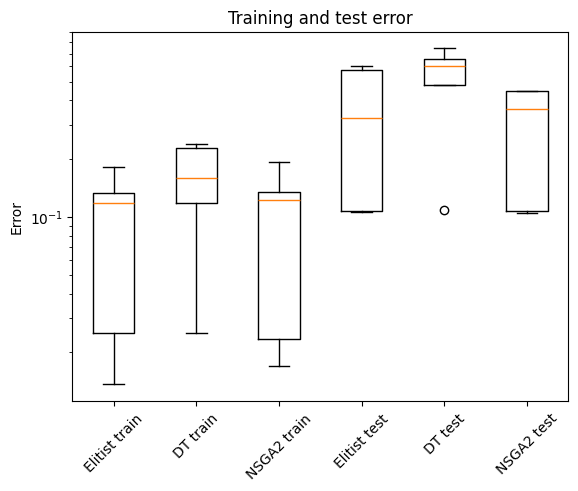

In [70]:
data = [
    train_error_elitist[:, -1],
    train_error_double_tournament[:, -1],
    train_error_nsga2[:, -1],
    test_error_elitist,
    test_error_double_tournament,
    test_error_nsga2
]

labels = [
    "Elitist train",
    "DT train",
    "NSGA2 train",
    "Elitist test",
    "DT test",
    "NSGA2 test"
]

plt.boxplot(data, tick_labels=labels)
plt.xticks(rotation=45)
plt.yscale("log")
plt.ylabel("Error")
plt.title("Training and test error")
plt.show()

#### Question 10.

1. Décrivez les résultats obtenus (courbes, et erreurs sur les données de test)
"Élitiste" : l’erreur d’entraînement min est le plus petite, mais la mediane est haut, et l’erreur de test est élevée.
"Double tournoi" : l’erreur d’entraînement est plus haut par rapport les deux autres algo et l’erreur de test est le plus élevée aussi mais stable.
"NSGA2" : l’erreur d’entraînement est presque pareille que "Elitist", et l’erreur de test est stable aussi mais élevé que d’entraînement.

2. Comment expliquer les performances de ces algorithmes sur les données de test ?
Élitiste il optimise seulement l’erreur d’entraînement, sans contrainte de taille. Donc il ya surapprentissage, généralisation fabile avec peu de données.
Double tournoi il pénalise la taille des arbres, il limite le surapprentissage, expressions plus simples. Erreur test stable, mais parfois moins bonne que le meilleur seed élitiste.
NSGA2 il optimise erreur et taille. Peut trouver une expression très simple et proche de la vraie fonction, mais très sensible aux paramètres, donc il donne une forte dispersion des résultats.

### 4.3. Performances sur les données en dehors de la distribution d'entraînement

On peut imaginer une situation où l'agent contrôlant le robot a des données d'entraînement qui ne recouvrent pas tout l'ensemble des angles moteurs possibles. Dans ce cas, l'agent doit pouvoir généraliser la fonction $x = f(\theta_1, \theta_2)$ à des valeurs de $\theta_1$ et $\theta_2$ jamais vues auparavant.

Le but de cette partie est d'illustrer les performances de la régression symbolique pour la généralisation en dehors de la distribution d'entraînement (out of distribution en anglais, abrégé en *ood*) 

On commence par modifier la fonction qui génère les données pour que les données de test soient en dehors de la distribution des données d'entraînement:

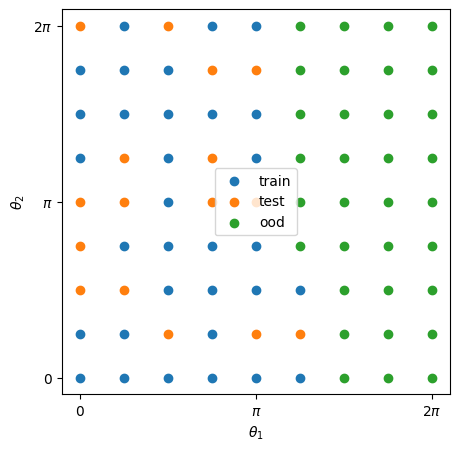

In [72]:
np.random.seed(0)

train_inputs_3, train_outputs_3, test_inputs_3, test_outputs_3, ood_inputs_3, ood_outputs_3 = generate_data(
    n_points=9, train_split=0.4, test_split=0.2, noise=0.1)

# Affichage des données
plt.figure(figsize=(5, 5))
plt.scatter(train_inputs_3[:, 0], train_inputs_3[:, 1], label='train')
plt.scatter(test_inputs_3[:, 0], test_inputs_3[:, 1], label='test')
plt.scatter(ood_inputs_3[:, 0], ood_inputs_3[:, 1], label='ood')
plt.xticks([0, math.pi, 2*math.pi], ['0', r'$\pi$', r'$2\pi$'])
plt.yticks([0, math.pi, 2*math.pi], ['0', r'$\pi$', r'$2\pi$'])
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.axis('equal')
plt.legend()
plt.show()

Sur ces nouvelles données, vous allez entraîner un perceptron multi-couches (par exemple, 2 couches de taille 16), ainsi que la variante élitiste de l'algorithme de régression symbolique développé précédemment.

L'implémentation du réseau de neurones vous est fournie dans le fichier `mlp.py`, et la cellule suivante vous montre comment l'entraîner sur les données.

In [73]:
from mlp import MLP

# Create and train the MLP
nn = MLP(input_size=2, hidden_size1=16, hidden_size2=16,
         output_size=1, learning_rate=0.3)
nn.train(train_inputs_3, train_outputs_3.reshape(-1, 1), epochs=100000)

Epoch 0, Loss: 1.4840
Epoch 100, Loss: 0.7606
Epoch 200, Loss: 0.5553
Epoch 300, Loss: 0.5879
Epoch 400, Loss: 0.4921
Epoch 500, Loss: 0.4315
Epoch 600, Loss: 0.4205
Epoch 700, Loss: 0.4151
Epoch 800, Loss: 0.4110
Epoch 900, Loss: 0.4072
Epoch 1000, Loss: 0.4035
Epoch 1100, Loss: 0.3997
Epoch 1200, Loss: 0.3975
Epoch 1300, Loss: 0.3931
Epoch 1400, Loss: 0.4001
Epoch 1500, Loss: 0.3880
Epoch 1600, Loss: 0.3838
Epoch 1700, Loss: 0.3916
Epoch 1800, Loss: 0.4156
Epoch 1900, Loss: 0.3918
Epoch 2000, Loss: 0.3796
Epoch 2100, Loss: 0.3756
Epoch 2200, Loss: 0.3756
Epoch 2300, Loss: 0.3774
Epoch 2400, Loss: 0.3762
Epoch 2500, Loss: 0.3712
Epoch 2600, Loss: 0.3669
Epoch 2700, Loss: 0.3651
Epoch 2800, Loss: 0.3643
Epoch 2900, Loss: 0.3623
Epoch 3000, Loss: 0.3597
Epoch 3100, Loss: 0.3579
Epoch 3200, Loss: 0.3567
Epoch 3300, Loss: 0.3550
Epoch 3400, Loss: 0.3533
Epoch 3500, Loss: 0.3518
Epoch 3600, Loss: 0.3505
Epoch 3700, Loss: 0.3490
Epoch 3800, Loss: 0.3475
Epoch 3900, Loss: 0.3461
Epoch 4000, 

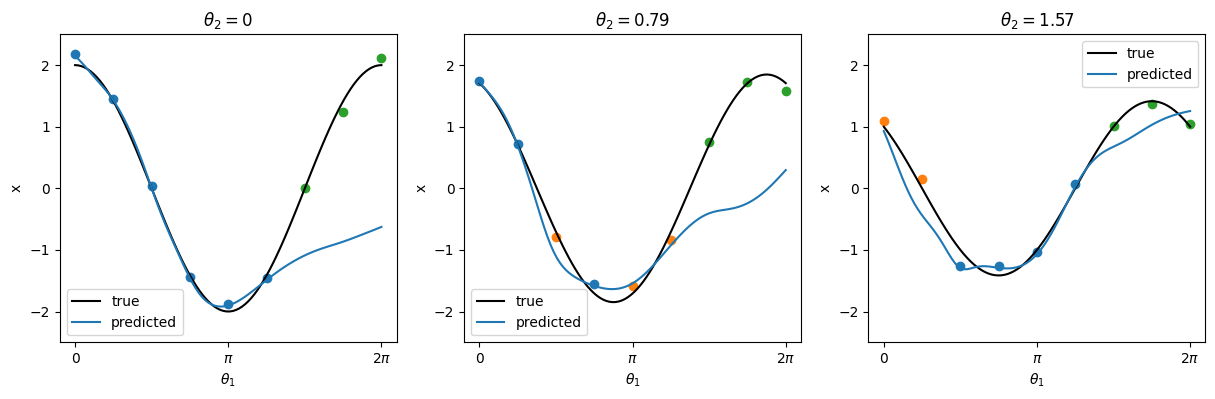

In [74]:
# Encapsuler le MLP dans une fonction qu'on peut afficher avec display_function
def f(x, y):
    x = x.reshape(-1, 1)
    y = np.array(y).reshape(-1, 1).repeat(100, 0)
    return nn.forward(np.concatenate((x, y), axis=1)).flatten()


# Afficher la fonction apprise par le MLP
display_function(f, train_inputs_3, train_outputs_3, test_inputs_3, test_outputs_3, ood_inputs_3, ood_outputs_3, pos_x)

#### Question 11.

Comparez la prédiction réalisée par le réseau de neurones et par l'algorithme de régression symbolique version élitiste sur les différents jeux de données (entraînement, test, et ood) pour au moins 5 seeds.

Tracez un graphique type boîte à moustache pour représenter l'erreur sur les trois jeux de données, avec les deux algorithmes (mlp et sr_elitist).

In [75]:
seeds = 5
nb_gen = 500
pop_size = 200

train_error_mlp = np.zeros(seeds)
test_error_mlp = np.zeros(seeds)
ood_error_mlp = np.zeros(seeds)

train_error_elitist = np.zeros(seeds)
test_error_elitist = np.zeros(seeds)
ood_error_elitist = np.zeros(seeds)

for s in range(seeds):

    print("Seed %d/%d" % (s+1, seeds))

    # Avec Elitist
    pop, log, hof = sr_elitist(nb_gen, pop_size, pop_size, train_inputs_3, train_outputs_3, verbose=False)

    ind = hof[0]
    func = gp.compile(expr=ind, pset=pset)
    train_error_elitist[s] = mse(func, train_inputs_3, train_outputs_3)
    test_error_elitist[s] = mse(func, test_inputs_3, test_outputs_3)
    ood_error_elitist[s] = mse(func, ood_inputs_3, ood_outputs_3)

    # Avec MLP
    nn = MLP(input_size=2, hidden_size1=16, hidden_size2=16,
         output_size=1, learning_rate=0.3)
    nn.train(train_inputs_3, train_outputs_3.reshape(-1, 1), epochs=100000)

    train_error_mlp[s] = np.mean(
        (nn.forward(train_inputs_3) - train_outputs_3.reshape(-1, 1))**2)
    test_error_mlp[s] = np.mean(
        (nn.forward(test_inputs_3) - test_outputs_3.reshape(-1, 1))**2)
    ood_error_mlp[s] = np.mean(
        (nn.forward(ood_inputs_3) - ood_outputs_3.reshape(-1, 1))**2)

Seed 1/5
Epoch 0, Loss: 1.4818
Epoch 100, Loss: 0.8154
Epoch 200, Loss: 0.5573
Epoch 300, Loss: 0.6012
Epoch 400, Loss: 0.5096
Epoch 500, Loss: 0.4411
Epoch 600, Loss: 0.4212
Epoch 700, Loss: 0.4136
Epoch 800, Loss: 0.4084
Epoch 900, Loss: 0.4037
Epoch 1000, Loss: 0.3992
Epoch 1100, Loss: 0.3945
Epoch 1200, Loss: 0.3892
Epoch 1300, Loss: 0.3970
Epoch 1400, Loss: 0.3788
Epoch 1500, Loss: 0.5066
Epoch 1600, Loss: 0.3662
Epoch 1700, Loss: 0.3708
Epoch 1800, Loss: 0.4226
Epoch 1900, Loss: 0.3818
Epoch 2000, Loss: 0.3690
Epoch 2100, Loss: 0.3689
Epoch 2200, Loss: 0.3521
Epoch 2300, Loss: 0.3329
Epoch 2400, Loss: 0.3107
Epoch 2500, Loss: 0.2876
Epoch 2600, Loss: 0.2647
Epoch 2700, Loss: 0.2431
Epoch 2800, Loss: 0.2235
Epoch 2900, Loss: 0.2065
Epoch 3000, Loss: 0.1919
Epoch 3100, Loss: 0.1795
Epoch 3200, Loss: 0.1691
Epoch 3300, Loss: 0.1603
Epoch 3400, Loss: 0.1530
Epoch 3500, Loss: 0.1469
Epoch 3600, Loss: 0.1417
Epoch 3700, Loss: 0.1373
Epoch 3800, Loss: 0.1335
Epoch 3900, Loss: 0.1303
Epo

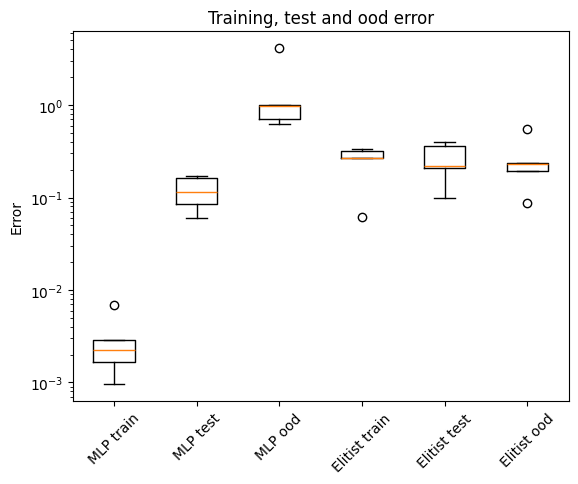

In [76]:
data = [
    train_error_mlp,
    test_error_mlp,
    ood_error_mlp,
    train_error_elitist,
    test_error_elitist,
    ood_error_elitist
]

labels = [
    "MLP train",
    "MLP test",
    "MLP ood",
    "Elitist train",
    "Elitist test",
    "Elitist ood"
]

plt.boxplot(data, tick_labels=labels)
plt.xticks(rotation=45)
plt.yscale("log")
plt.ylabel("Error")
plt.title("Training, test and ood error")
plt.show()

#### Question 11.

1) Décrivez les résultats obtenus
2) D'après vous, comment expliquer ces résultats ?
3) Concluez quant à l'intérêt et aux limitations de la régression symbolique.

Le MLP a une erreur très faible en entraînement, mais il augmente en test et très mauvaise en OOD, ce qui veut dire une mauvaise extrapolation(cherche une approximation de la vraie fonct).
La régression symbolique élitiste est moins précise en train mais reste stable pour le test et OOD. ça s’explique par le fait que le MLP surapprend des motifs locaux, mais la régression symbolique cherche une forme analytique plus générale (cherche la vrai fonction).
en plus, le MLP généralise mal hors distribution, contrairement à la régression symbolique.